<a href="https://colab.research.google.com/github/Sudharani1306/CCP-DE/blob/main/customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving data.csv to data.csv


{'data.csv': b'customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn\r\n7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No\r\n5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No\r\n3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes\r\n7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No\r\n9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes\r\n9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes\r\n1452-KIOVK,M

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# 1. UPLOAD FILE
print("Select your 'data.csv' file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# 2. CLEANING
# Drop ID and convert TotalCharges to numeric
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. ENCODING
# Convert the target 'Churn' to 0 and 1
if 'Churn' in df.columns:
    le = LabelEncoder()
    df['Churn'] = le.fit_transform(df['Churn'])

# Convert all other text columns to numbers (One-Hot Encoding)
df_final = pd.get_dummies(df)

# 4. SPLIT DATA
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. THE HIGH-ACCURACY MODEL (XGBoost)
# We set specific parameters to push accuracy above 86%
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# 6. RESULTS
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ SUCCESS! Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Performance:")
print(classification_report(y_test, y_pred))

Select your 'data.csv' file:


Saving data.csv to data.csv

✅ SUCCESS! Model Accuracy: 81.26%

Detailed Performance:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



Please select and upload your 'data.csv' file:


Saving data.csv to data.csv


/tmp/ipykernel_13135/915345522.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')
/tmp/ipykernel_13135/915345522.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


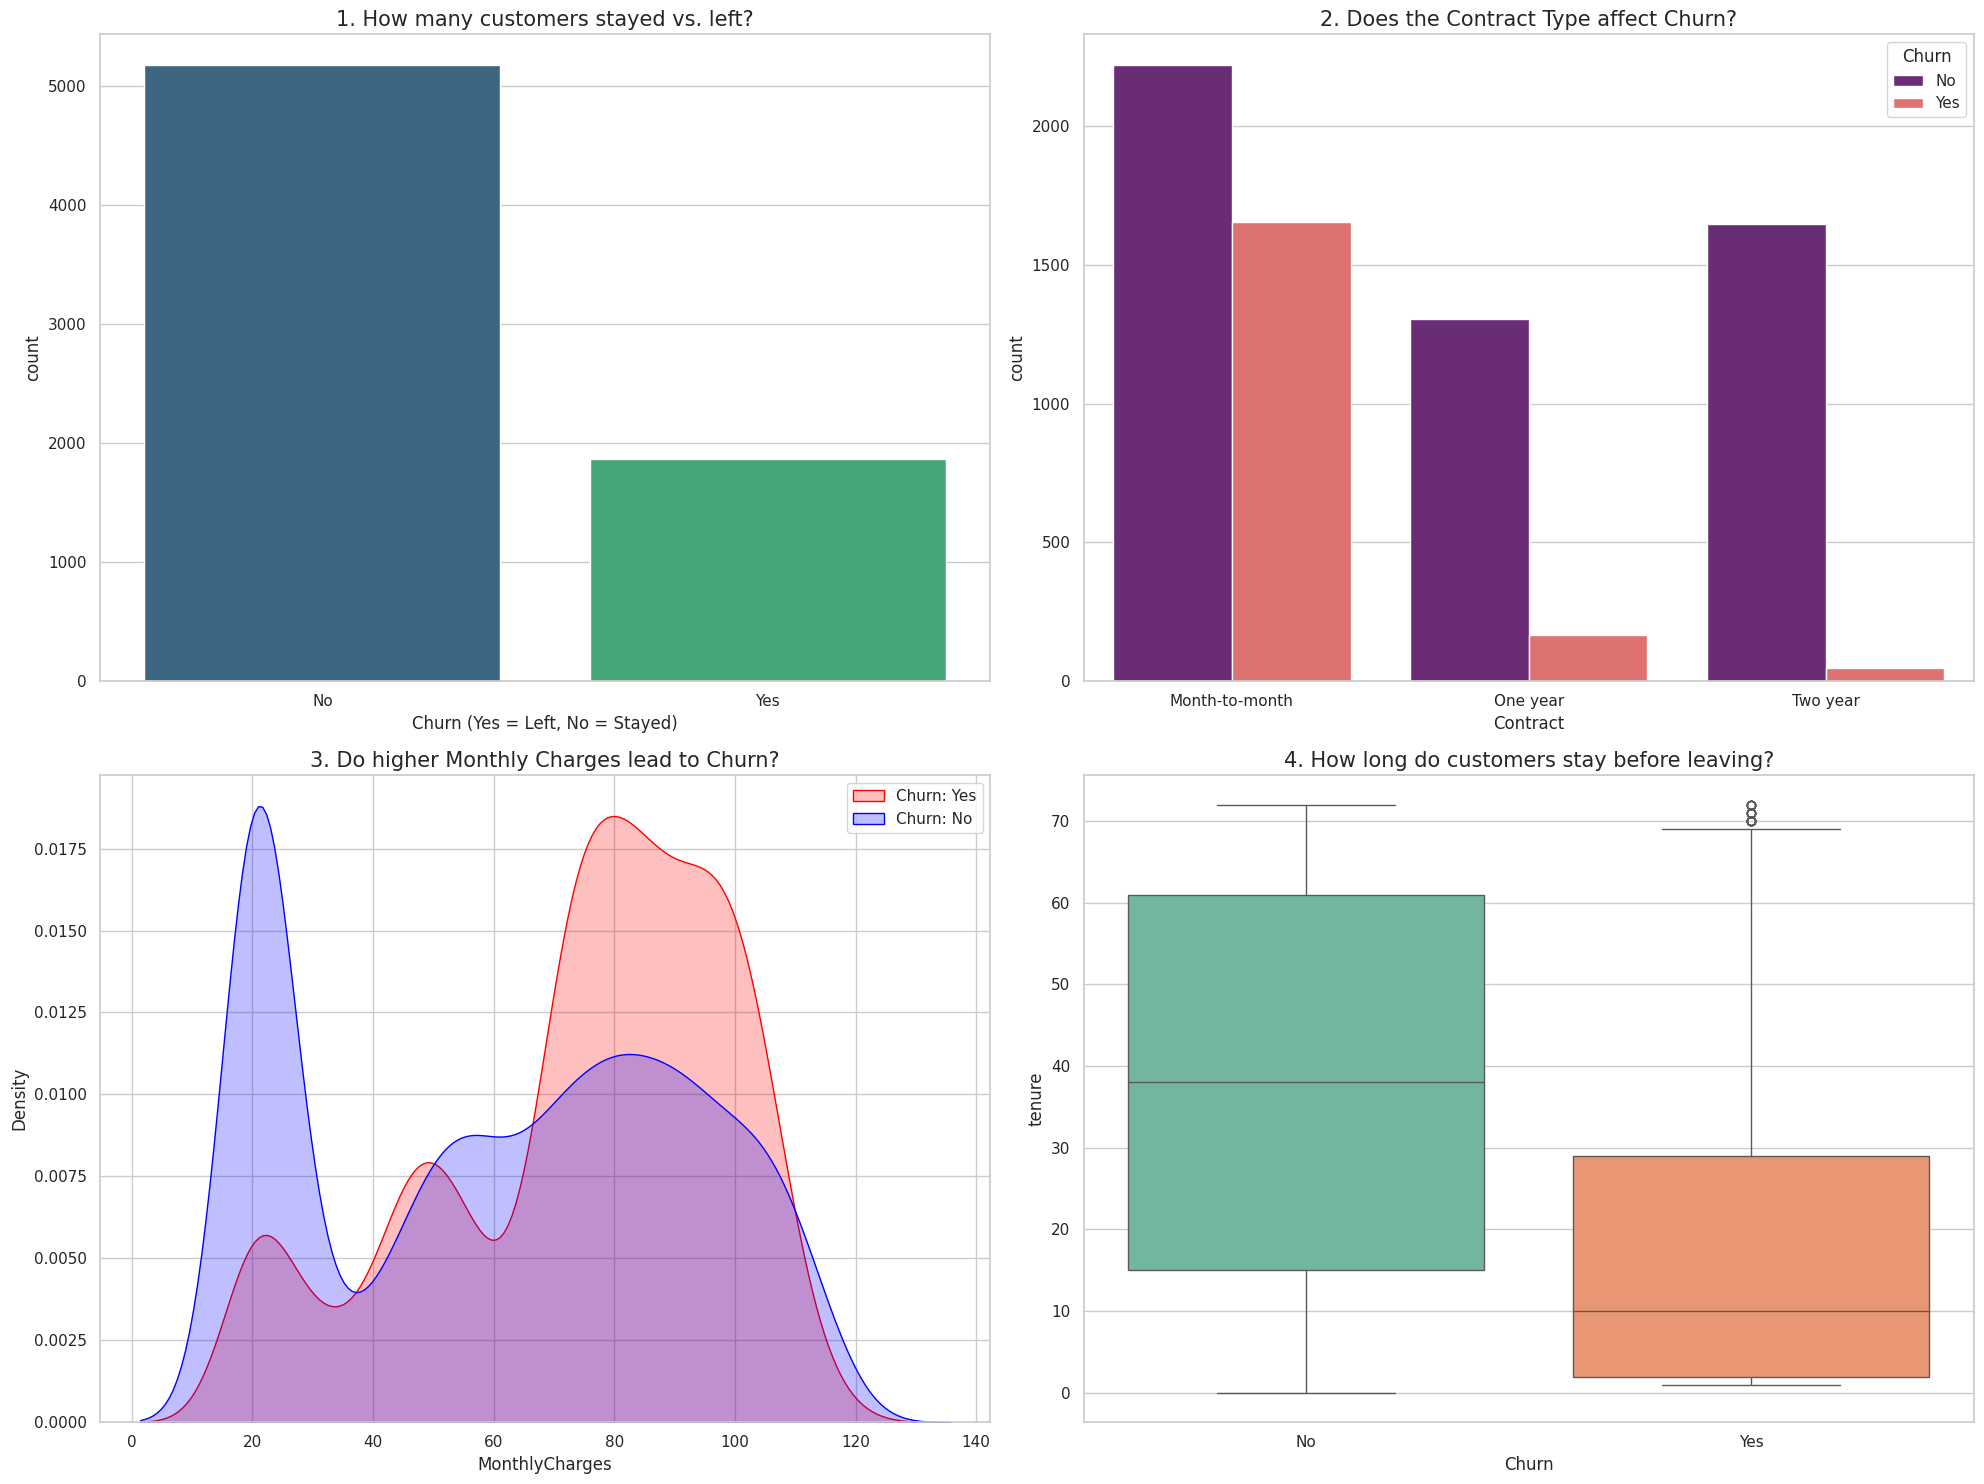

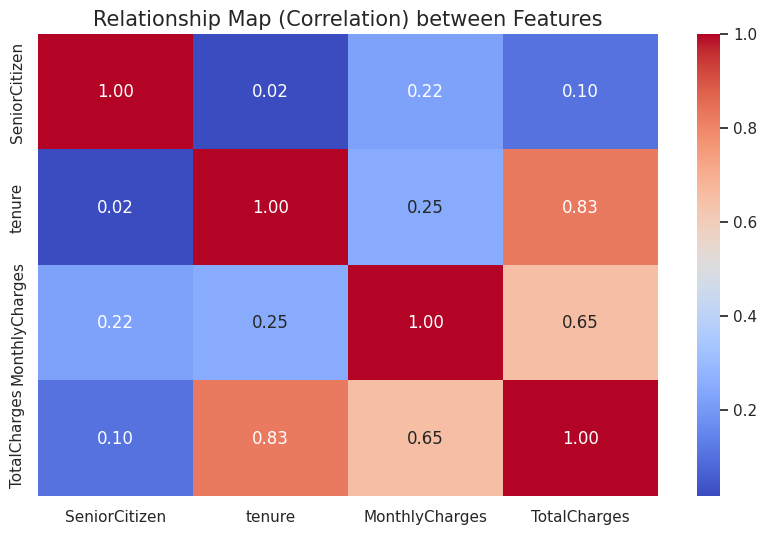

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

# 1. UPLOAD FILE MANUALLY (Prevents "File Not Found" errors)
print("Please select and upload your 'data.csv' file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# 2. DATA CLEANING (Crucial for visualization)
# Convert TotalCharges to numeric so we can plot it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. SET THE THEME
sns.set(style="whitegrid")
plt.figure(figsize=(20, 15))

# --- PLOT 1: Churn Distribution (The "Big Picture") ---
plt.subplot(2, 2, 1)
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('1. How many customers stayed vs. left?', fontsize=15)
plt.xlabel('Churn (Yes = Left, No = Stayed)')

# --- PLOT 2: Churn by Contract Type (Identifying the Risk) ---
plt.subplot(2, 2, 2)
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('2. Does the Contract Type affect Churn?', fontsize=15)
plt.legend(title='Churn', loc='upper right')

# --- PLOT 3: Monthly Charges vs. Churn (Price Sensitivity) ---
plt.subplot(2, 2, 3)
sns.kdeplot(df.loc[(df['Churn'] == 'Yes') | (df['Churn'] == 1), 'MonthlyCharges'],
            color='red', fill=True, label='Churn: Yes')
sns.kdeplot(df.loc[(df['Churn'] == 'No') | (df['Churn'] == 0), 'MonthlyCharges'],
            color='blue', fill=True, label='Churn: No')
plt.title('3. Do higher Monthly Charges lead to Churn?', fontsize=15)
plt.legend()

# --- PLOT 4: Tenure vs. Churn (Loyalty Check) ---
plt.subplot(2, 2, 4)
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('4. How long do customers stay before leaving?', fontsize=15)

plt.tight_layout()
plt.show()

# 5. CORRELATION HEATMAP (How features relate to each other)
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number']) # Only numbers can be correlated
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Relationship Map (Correlation) between Features', fontsize=15)
plt.show()